# 5.4 自然言語推論・意味的類似度計算・多肢選択式質問応答モデルの実装

## 5.4.1 自然言語推論
NLI: Natural Language Inference

### 環境の準備

In [1]:
!pip install 'datasets<4.0.0' 'transformers[ja,torch]<4.41.0'  matplotlib scikit-learn

In [2]:
# transformers 4.40.2 と Colab プリインストールの新しい peft が非互換
# (peft が EncoderDecoderCache を要求するが transformers 4.40 には存在しない)
# このノートブックでは peft を使わないのでアンインストールして回避する
%pip uninstall -y peft

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1


In [3]:
from transformers.trainer_utils import set_seed

# 乱数シードを42に固定
set_seed(42)

### データセットの読み込み

In [4]:
from pprint import pprint
from datasets import load_dataset

train_dataset = load_dataset(
    "llm-book/JGLUE",
    name="JNLI",
    split="train"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [5]:
pprint(train_dataset)
print(train_dataset["sentence1"][:2])
print(train_dataset["sentence2"][:2])
print(train_dataset["label"])


Dataset({
    features: ['sentence_pair_id', 'yjcaptions_id', 'sentence1', 'sentence2', 'label'],
    num_rows: 20073
})
['二人の男性がジャンボジェット機を見ています。', '2人の男性が、白い飛行機を眺めています。']
['2人の男性が、白い飛行機を眺めています。', '二人の男性がジャンボジェット機を見ています。']
[2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 0, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 1, 1, 1, 1, 2, 1, 1, 0, 0, 2, 2,

In [6]:
print(train_dataset["yjcaptions_id"][:2])


['100124-104404-104405', '100124-104405-104404']


In [7]:
print(train_dataset.features["label"])

ClassLabel(names=['entailment', 'contradiction', 'neutral'], id=None)


In [8]:
valid_dataset = load_dataset(
    "llm-book/JGLUE",
    name="JNLI",
    split="validation"
)

In [9]:
pprint(train_dataset[0])

{'label': 2,
 'sentence1': '二人の男性がジャンボジェット機を見ています。',
 'sentence2': '2人の男性が、白い飛行機を眺めています。',
 'sentence_pair_id': '0',
 'yjcaptions_id': '100124-104404-104405'}


### トークナイザ

In [10]:
from transformers import AutoTokenizer

model_name = "cl-tohoku/bert-base-japanese-v3"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


### データセット統計の可視化

100%|██████████| 20073/20073 [00:05<00:00, 3902.88it/s]


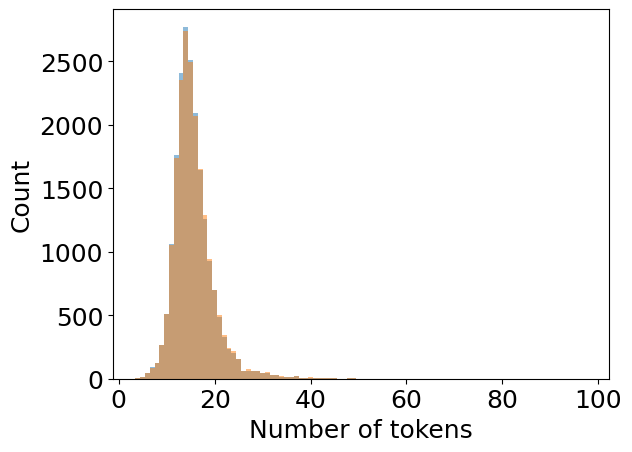

100%|██████████| 2434/2434 [00:00<00:00, 4003.08it/s]


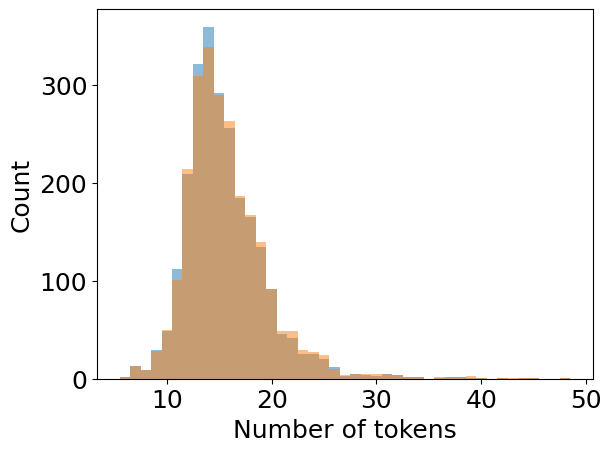

In [11]:
from collections import Counter
import matplotlib.pyplot as plt
from datasets import Dataset
from tqdm import tqdm

plt.rcParams["font.size"] = 18  # 文字サイズを大きくする

def visualize_text_length(dataset: Dataset):
    """データセット中のテキストのトークン数の分布をグラフとして描画"""
    # データセット中のテキストの長さを数える
    length_counter1 = Counter()
    length_counter2 = Counter()
    for data in tqdm(dataset):
        length1 = len(tokenizer.tokenize(data["sentence1"]))
        length_counter1[length1] += 1
        length2 = len(tokenizer.tokenize(data["sentence2"]))
        length_counter2[length2] += 1
    # length_counterの値から棒グラフを描画する
    plt.bar(length_counter1.keys(), length_counter1.values(), width=1.0, alpha=0.5)
    plt.bar(length_counter2.keys(), length_counter2.values(), width=1.0, alpha=0.5)
    plt.xlabel("Number of tokens")
    plt.ylabel("Count")
    plt.show()

visualize_text_length(train_dataset)
visualize_text_length(valid_dataset)

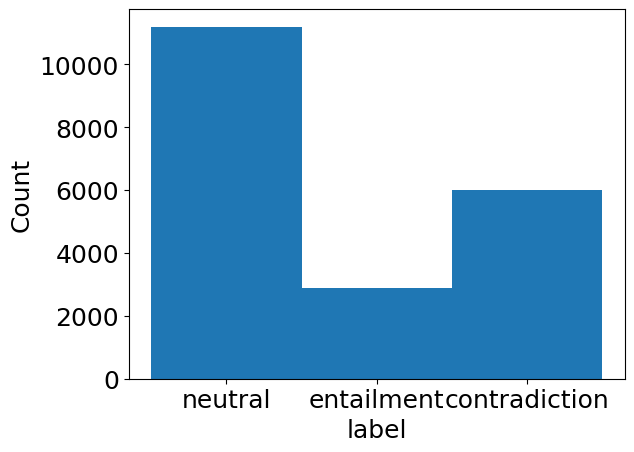

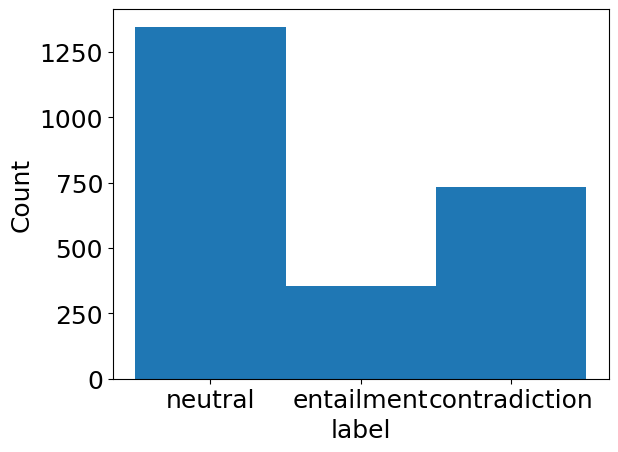

In [12]:
def visualize_labels(dataset: Dataset):
    """データセット中のラベル分布をグラフとして描画"""
    # データセット中のラベルを数える
    label_counter = Counter()
    for data in dataset:
        label_id = data["label"]
        label_name = dataset.features["label"].names[label_id]
        label_counter[label_name] += 1
    # label_counterを棒グラフとして描画する
    plt.bar(label_counter.keys(), label_counter.values(), width=1.0)
    plt.xlabel("label")
    plt.ylabel("Count")
    plt.show()

visualize_labels(train_dataset)
visualize_labels(valid_dataset)

### データセットの前処理

In [13]:
from transformers import BatchEncoding

def preprocess_text_pair_classification(
        example: dict[str, str | int]
) -> BatchEncoding:
    """文ペア関係予測の事例をトークナイズし、IDに変換"""
    # 出力は"input_ids", "token-type_ids", "attention_mask"
    # list[int] をvalueとするBatchEncodingオブジェクト
    encoded_example = tokenizer(
        example["sentence1"], example["sentence2"], max_length=128
    )
    # 以降で使うモデルのBertForSequenceClassificationのforwardメソッドが
    # 受け取るラベルの引数名に合わせて"labels"をキーにする
    encoded_example["labels"] = example["label"]
    return encoded_example

In [14]:
encoded_train_dataset = train_dataset.map(
    preprocess_text_pair_classification,
    remove_columns=train_dataset.column_names,
)
encoded_valid_dataset = valid_dataset.map(
    preprocess_text_pair_classification,
    remove_columns=valid_dataset.column_names,
)

Parameter 'function'=<function preprocess_text_pair_classification at 0x788188cdb2e0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/20073 [00:00<?, ? examples/s]

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


Map:   0%|          | 0/2434 [00:00<?, ? examples/s]

In [15]:
print(train_dataset[0])
print(encoded_train_dataset[0])

{'sentence_pair_id': '0', 'yjcaptions_id': '100124-104404-104405', 'sentence1': '二人の男性がジャンボジェット機を見ています。', 'sentence2': '2人の男性が、白い飛行機を眺めています。', 'label': 2}
{'input_ids': [2, 14269, 464, 13341, 430, 27914, 16753, 3107, 500, 5538, 456, 422, 12995, 385, 3, 33, 680, 464, 13341, 430, 384, 16517, 13208, 3107, 500, 29887, 456, 422, 12995, 385, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 2}


### ミニバッチ構築

In [16]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [17]:
batch_inputs = data_collator(encoded_train_dataset[:4])
pprint({name: tensor.size() for name, tensor in batch_inputs.items()})

{'attention_mask': torch.Size([4, 31]),
 'input_ids': torch.Size([4, 31]),
 'labels': torch.Size([4]),
 'token_type_ids': torch.Size([4, 31])}


### モデルの準備

In [18]:
from transformers import AutoModelForSequenceClassification

class_label = train_dataset.features["label"]
label2id = {label: id for id, label in enumerate(class_label.names)}
id2label = {id: label for id, label in enumerate(class_label.names)}
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=class_label.num_classes,
    label2id=label2id,
    id2label=id2label
)
# パラメータをメモリ上に隣接した形で配置
# これを実行しない場合、モデルの保存でエラーになることがある
for param in model.parameters():
    param.data = param.data.contiguous()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-v3 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
print(model.forward(**data_collator(encoded_train_dataset[0:4])))

SequenceClassifierOutput(loss=tensor(0.9288, grad_fn=<NllLossBackward0>), logits=tensor([[-0.6427,  0.1023,  0.7199],
        [-0.6226,  0.1166,  0.7084],
        [-0.7004,  0.1018,  0.6902],
        [-0.6722,  0.0833,  0.6754]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)


### 訓練の実行

In [20]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="output_jnli",          # 結果の保存フォルダ
    per_device_train_batch_size=32,    # 訓練時のバッチサイズ
    per_device_eval_batch_size=32,     # 評価時のバッチサイズ
    learning_rate=2e-5,                # 学習率
    lr_scheduler_type="linear",        # 学習率スケジューラの種類
    warmup_ratio=0.1,                  # 学習率のウォームアップの長さを指定
    num_train_epochs=3,                # エポック数
    save_strategy="epoch",             # チェックポイントの保存タイミング
    logging_strategy="epoch",          # ロギングのタイミング
    evaluation_strategy="epoch",       # 検証セットによる評価のタイミング
    load_best_model_at_end=True,       # 訓練後に開発セットで最良のモデルをロード
    metric_for_best_model="accuracy",  # 最良のモデルを決定する評価指標
    fp16=True,                         # 自動混合精度演算の有効化
    report_to="none",                  # 外部ツールへのログを無効化
)

In [21]:
import numpy as np

def compute_accuracy(
    eval_pred: tuple[np.ndarray, np.ndarray]
) -> dict[str, float]:
    """予測ラベルと正解ラベルから正解率を計算"""
    predictions, labels = eval_pred
    # predictionsは各ラベルについてのスコア
    # 最もスコアの高いインデックスを予測ラベルとする
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": (predictions == labels).mean()}

In [22]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    train_dataset=encoded_train_dataset,
    eval_dataset=encoded_valid_dataset,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_accuracy,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.485200,0.274665,0.898521
2,0.212600,0.286875,0.900575
3,0.129100,0.323371,0.904273


TrainOutput(global_step=1884, training_loss=0.2756464891372972, metrics={'train_runtime': 283.2857, 'train_samples_per_second': 212.573, 'train_steps_per_second': 6.651, 'total_flos': 1655145273928230.0, 'train_loss': 0.2756464891372972, 'epoch': 3.0})

### 訓練後のモデルの評価

In [23]:
# 検証セットでモデルを評価
eval_metrics = trainer.evaluate(encoded_valid_dataset)
pprint(eval_metrics)

{'epoch': 3.0,
 'eval_accuracy': 0.9042728019720625,
 'eval_loss': 0.3233707845211029,
 'eval_runtime': 2.2462,
 'eval_samples_per_second': 1083.608,
 'eval_steps_per_second': 34.28}


### モデルの保存

#### Hugging Face Hubへの保存

In [ ]:
from huggingface_hub import login
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get("HF_TOKEN"))

login()

# Hugging Face Hubのリポジトリ名
repo_name = "tact-m/bert-base-japanese-v3-jnli"
# トークナイザとモデルをアップロード
tokenizer.push_to_hub(repo_name)
model.push_to_hub(repo_name)

HfHubHTTPError: 401 Client Error: Unauthorized for url: https://huggingface.co/api/repos/create (Request ID: Root=1-69efff0f-3fdf670c320eae22623e4ccc;a6ff0f3c-72cc-4b1b-ac5a-877352ad91ea)

Invalid username or password.